# 🟢 Chapter 3: Unsupervised Learning and Preprocessing
**Referensi:** *Introduction to Machine Learning with Python* (Andreas C. Müller & Sarah Guido)
---
> **Author:** Dhafi Dzakwan Pratama | 101032300213
> **Topik:** Data Preprocessing, Dimensionality Reduction (PCA), dan Clustering
---
## 1. Unsupervised Learning & Preprocessing
Dalam *Unsupervised Learning*, algoritma diberikan data tanpa label (tanpa *output* yang diketahui). Algoritma ini sering digunakan untuk memahami struktur data. Salah satu langkah terpenting sebelum melatih model (baik supervised maupun unsupervised) adalah **Preprocessing** atau penskalaan fitur.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

%matplotlib inline

## 2. Visualisasi Efek Scaling pada Data
Buku ini menekankan pentingnya *Scaling* (seperti `MinMaxScaler` atau `StandardScaler`) untuk algoritma seperti SVM atau Neural Networks. Mari kita visualisasikan bagaimana data berubah bentuk (skalanya) setelah dilakukan *preprocessing* menggunakan data sintetis.

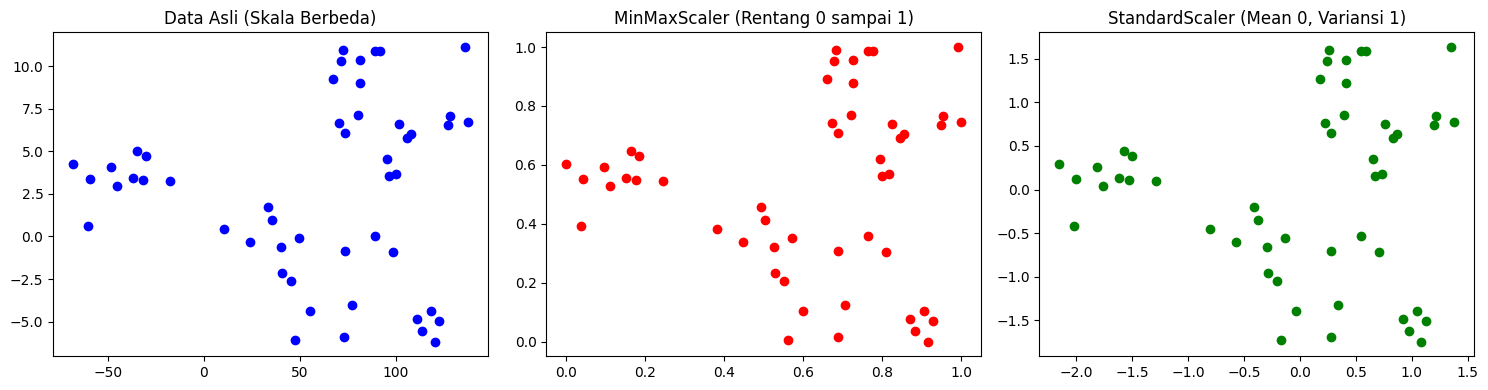

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Membuat data sintetis
X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X[:, 0] *= 10  # Membuat skala fitur pertama jauh lebih besar
X[:, 1] += 5

# Mengaplikasikan Scaler
X_minmax = MinMaxScaler().fit_transform(X)
X_standard = StandardScaler().fit_transform(X)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X[:, 0], X[:, 1], c='blue')
axes[0].set_title("Data Asli (Skala Berbeda)")
axes[1].scatter(X_minmax[:, 0], X_minmax[:, 1], c='red')
axes[1].set_title("MinMaxScaler (Rentang 0 sampai 1)")
axes[2].scatter(X_standard[:, 0], X_standard[:, 1], c='green')
axes[2].set_title("StandardScaler (Mean 0, Variansi 1)")
plt.tight_layout();

## 3. Dimensionality Reduction: Principal Component Analysis (PCA)
PCA adalah teknik *Unsupervised* untuk mengurangi dimensi data dengan tetap mempertahankan sebanyak mungkin variansi/informasi. Ini sangat berguna untuk memvisualisasikan data berdimensi tinggi (seperti dataset Cancer yang memiliki 30 fitur) ke dalam 2D.

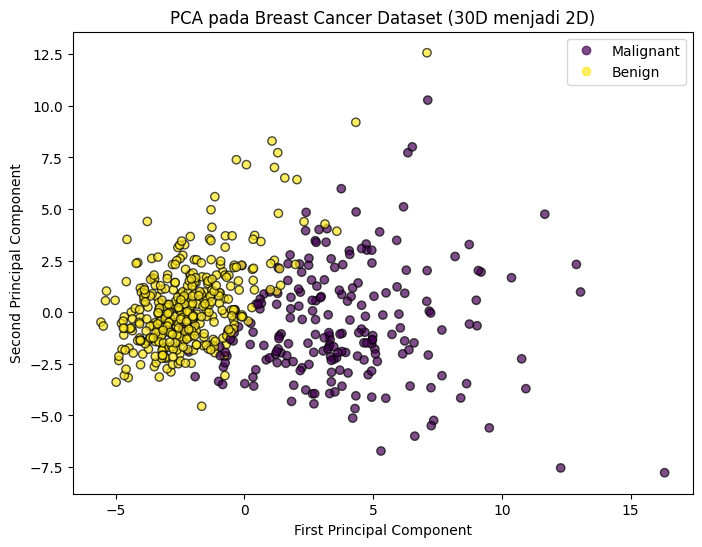

In [3]:
from sklearn.decomposition import PCA

cancer = load_breast_cancer()

# Penting: PCA sangat sensitif terhadap skala data, jadi kita harus standarisasi dulu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)

# Mengurangi data menjadi 2 komponen utama saja
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cancer.target, cmap='viridis', alpha=0.7, edgecolors='k')
plt.legend(handles=scatter.legend_elements()[0], labels=['Malignant', 'Benign'])
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA pada Breast Cancer Dataset (30D menjadi 2D)");

## 4. Clustering: K-Means
Clustering adalah tugas mempartisi dataset ke dalam grup-grup (*clusters*). **K-Means** adalah salah satu algoritma clustering yang paling terkenal, yang mencoba menemukan titik pusat (*centroids*) untuk setiap cluster.

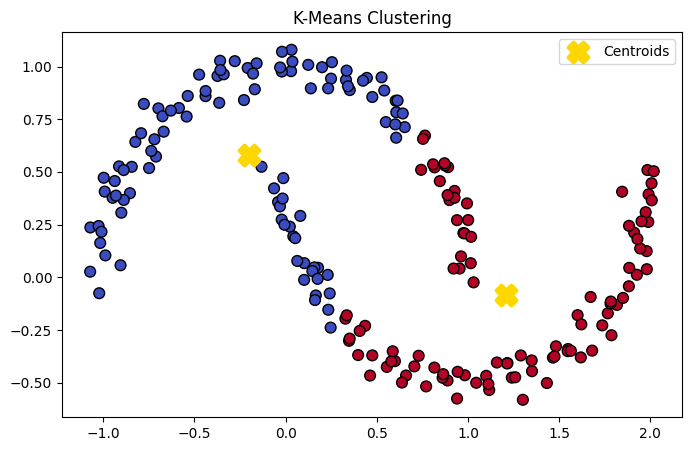

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons

# Membuat dataset sintetis berbentuk bulan sabit
X_moon, _ = make_moons(n_samples=200, noise=0.05, random_state=0)

# Clustering dengan K-Means (Mencari 2 kelompok)
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(X_moon)

# Visualisasi hasil clustering
plt.figure(figsize=(8, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans.labels_, cmap='coolwarm', s=60, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=200, linewidths=3, color='gold', zorder=10, label="Centroids")
plt.title("K-Means Clustering")
plt.legend();

*Catatan: K-Means memisahkan data berdasarkan jarak lurus terdekat ke centroid, sehingga pada dataset kompleks seperti bentuk lengkung di atas, ia gagal menangkap bentuk alami datanya. Ini adalah contoh batasan K-Means yang dibahas pada buku.*